In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [2]:
import pandas
import matplotlib.pyplot as plot
import numpy

data = pandas.read_csv('confirmed_exoplanet_data.csv')
data['radius'] *= 11.2089
data['mass'] *= 317.906
data = data[['radius', 'mass']].dropna().reset_index(drop = True)
data = data.sort_values('radius').reset_index(drop = True)
data = data.reset_index(drop = True)
data.min(), data.max()

(radius    0.291431
 mass      0.060402
 dtype: float64,
 radius      77.34141
 mass      4100.98740
 dtype: float64)

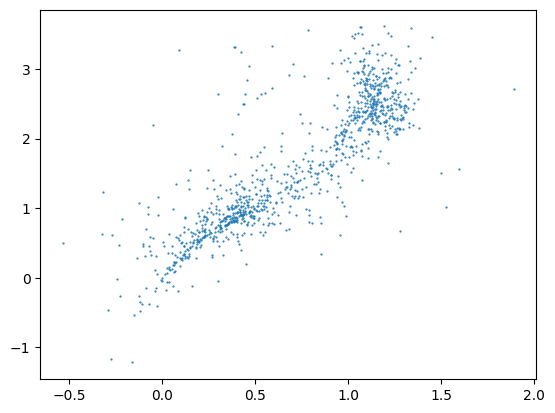

In [3]:
x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)

_, unique_indices = numpy.unique(x, return_index = True)
x, y = x[unique_indices], y[unique_indices]

# mask = (-0.25 < x) & (x < 1.5)
# x, y = x[mask], y[mask]

plot.scatter(x, y, s = 0.3)
# plot.loglog()
plot.show()

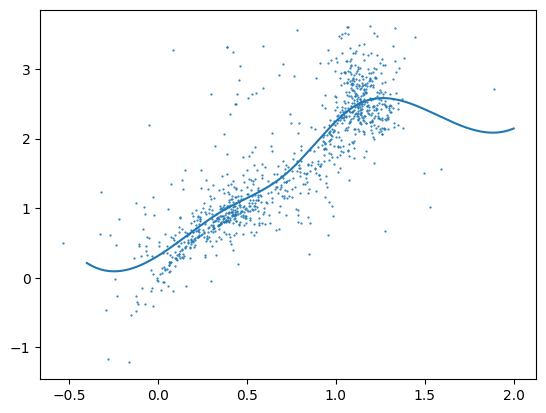

In [79]:
from scipy.interpolate import UnivariateSpline

spline = UnivariateSpline(x, y, k = 3, s = 215)

x_smooth = numpy.linspace(-0.4, 2, 10000)
y_smooth = spline(x_smooth)

plot.scatter(x, y, s = 0.3)
plot.plot(x_smooth, y_smooth)
plot.show()

In [98]:
from LogRMSpline import LogRMSpline

spline = LogRMSpline(spline, x, y)
spline.cap_min(-0.24642464246424645, 0.09199604411586669)
spline.cap_max(1.2643014301430142, 2.582845159184549)

In [99]:
import pickle

with open('conf_radius_mass_spline.pkl', 'wb') as file:
    pickle.dump(spline, file)

Log Min: -0.75, -0.41157931341988685
Log Max: 1.2643014301430142, 2.582845159184549
Log Spread: 0.46215464666488115


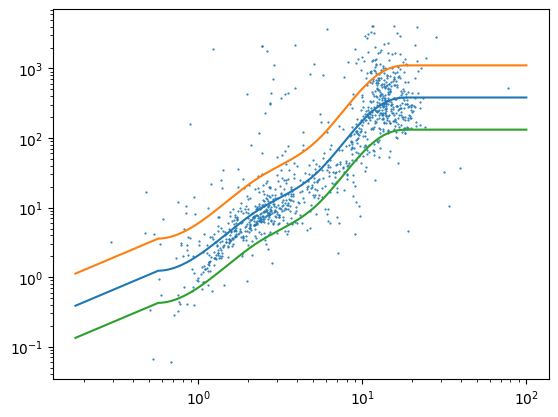

In [100]:
import pickle
import matplotlib.pyplot as plot
import numpy

with open('conf_radius_mass_spline.pkl', 'rb') as file:
    spline = pickle.load(file)

x_smooth = numpy.linspace(-0.75, 2, 10000)
y_smooth = spline(x_smooth)

print(f'Log Min: {x_smooth[numpy.argmin(y_smooth)]}, {numpy.min(y_smooth)}')
print(f'Log Max: {x_smooth[numpy.argmax(y_smooth)]}, {numpy.max(y_smooth)}')
print(f'Log Spread: {spline.spread}')

# y_smooth[x_smooth < x_smooth[numpy.argmin(y_smooth)]] = y_smooth[numpy.argmin(y_smooth)]
# y_smooth[x_smooth > x_smooth[numpy.argmax(y_smooth)]] = y_smooth[numpy.argmax(y_smooth)]

# plot.scatter(x, y, s = 0.3)
# plot.plot(x_smooth, y_smooth)
# plot.plot(numpy.linspace(numpy.min(x_smooth), numpy.max(x_smooth), 10), numpy.linspace(numpy.log10(4130), numpy.log10(4130), 10))

plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth + spline.spread))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth - spline.spread))
plot.scatter(numpy.power(10, x), numpy.power(10, y), s = 0.3)

# plot.plot(10 ** x_smooth, spline.predict_linear(10 ** x_smooth))
plot.loglog()
plot.show()